In [99]:
import numpy as np
import matplotlib.pyplot as plt
import athena_mc as athenamc
from scipy.optimize import curve_fit
from scipy.integrate import quad
import final_proj as fitting

Test case 1

In [102]:
A_pow_true = 1e29
alpha_true = 2.0

A_bb_true = 1e20
Tin_true = 500
Tout_true = 50

In [103]:
x = np.logspace(2, 4, 100)

y_true = fitting.comp(x, A_pow_true, alpha_true, A_bb_true, Tin_true, Tout_true)

rng = np.random.default_rng(42)
frac_noise = 0.1
yerr = frac_noise * y_true
noise = rng.normal(0, yerr)

y_fake = y_true + noise

In [104]:
results = fitting.composite(x, y_fake, yerr)

A_pow_fit = results[0]
alpha_fit = results[2]

A_bb_fit = results[4]
Tin_fit  = results[6]
Tout_fit = results[8]

print("TRUE PARAMETERS")
print(f"A_pow  = {A_pow_true:.3e}")
print(f"alpha  = {alpha_true:.3f}")
print(f"A_bb   = {A_bb_true:.3e}")
print(f"Tin    = {Tin_true:.3f}")
print(f"Tout   = {Tout_true:.3f}")

print("\nFITTED PARAMETERS")
print(f"A_pow  = {A_pow_fit:.3e}")
print(f"alpha  = {alpha_fit:.3f}")
print(f"A_bb   = {A_bb_fit:.3e}")
print(f"Tin    = {Tin_fit:.3f}")
print(f"Tout   = {Tout_fit:.3f}")

Composite fit parameters:
A_pow  = -2.827e+26 ± inf
alpha  = 3722.614 ± inf
A_bb   = 1.023e+20 ± inf
Tin    = 498.210 ± inf
Tout   = 51.299 ± inf

TRUE PARAMETERS
A_pow  = 1.000e+29
alpha  = 2.000
A_bb   = 1.000e+20
Tin    = 500.000
Tout   = 50.000

FITTED PARAMETERS
A_pow  = -2.827e+26
alpha  = 3722.614
A_bb   = 1.023e+20
Tin    = 498.210
Tout   = 51.299


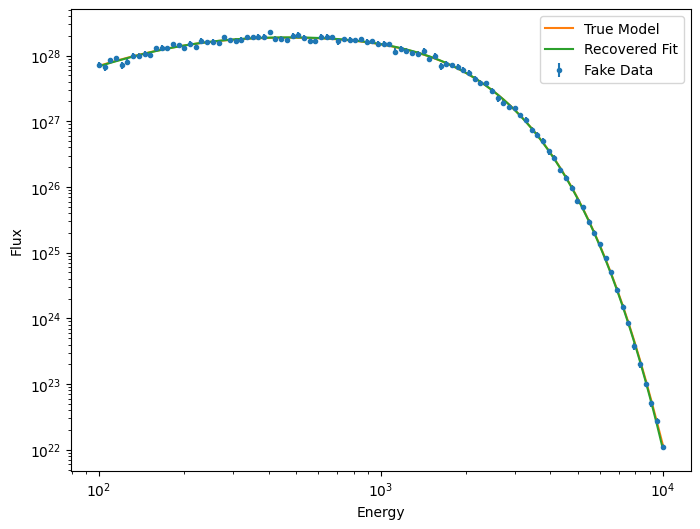

In [105]:
plt.figure(figsize=(8,6))

plt.errorbar(x, y_fake, yerr=yerr, fmt='o', label='Fake Data', markersize=3)

plt.plot(x, y_true, label='True Model')

plt.plot(x, fitting.comp(x, A_pow_fit, alpha_fit, A_bb_fit, Tin_fit, Tout_fit), label='Recovered Fit')

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Energy")
plt.ylabel("Flux")

plt.legend()

plt.show()

Test case 2